# Análisis y visualización de datos con Python
# 12. Mapas con GeoPandas

    - a) Formatos de archivo geoespaciales
    - b) Marco geoestadístico y catálogo de localidad
    - c) Información geoespacial 
    - d) Mapas
    - e) Mapa con datos propios
    - f) Temas adicionales
    - g) Resumen
    
---

GeoPandas es una biblioteca de Python de código abierto que se utiliza para trabajar con datos geoespaciales. Esta biblioteca se basa en las bibliotecas de Pandas y Shapely, proporcionando una manera fácil de manejar datos geoespaciales de una manera similar a como se manejan los datos tabulares en Pandas.

GeoPandas permite la lectura, escritura y manipulación de datos geoespaciales en diferentes formatos como Shapefile, GeoJSON y otros. También proporciona herramientas para realizar operaciones espaciales y de análisis de datos, como intersectar, unir y agrupar datos basados en la ubicación espacial.

GeoPandas se utiliza comúnmente en aplicaciones de análisis de datos geoespaciales, visualización y mapeo, así como en aplicaciones de aprendizaje automático que utilizan datos geoespaciales.

In [2]:
#! pip install geopandas
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


## 12.a Formatos de archivo geoespaciales

Existen varios formatos de archivo geoespacial que se utilizan para almacenar y compartir datos geográficos. Algunos de los formatos de archivo geoespacial más comunes son:

* Shapefile: Es un formato de archivo vectorial desarrollado por ESRI, que se utiliza comúnmente en sistemas de información geográfica (SIG) para almacenar datos geográficos. Los shapefiles pueden contener puntos, líneas y polígonos, y se utilizan comúnmente para representar características geográficas como ríos, carreteras, edificios, etc.
* GeoJSON: Es un formato de archivo de datos geoespaciales en formato JSON (JavaScript Object Notation), que se utiliza para almacenar datos vectoriales. GeoJSON se utiliza comúnmente en aplicaciones web y móviles para visualizar datos geográficos.
* DBF (DataBase File): Es un formato de archivo utilizado para almacenar datos tabulares en un archivo de base de datos. Fue desarrollado por la empresa de software dBase en los años 80, y se ha convertido en un formato común para el intercambio de datos entre diferentes programas de software.
* CSV: Es un formato de archivo de texto utilizado para almacenar datos tabulares, incluyendo datos geoespaciales. Los datos geoespaciales en formato CSV suelen incluir coordenadas geográficas, como latitud y longitud.
* KML/KMZ: Es un formato de archivo desarrollado por Google para almacenar datos geográficos en 3D, como modelos de terreno, edificios y objetos. Los archivos KML se pueden ver en Google Earth y en otras aplicaciones SIG.
* GML: Es un formato de archivo XML (Extensible Markup Language) utilizado para intercambiar datos geoespaciales entre diferentes aplicaciones SIG.
* TopoJSON: Es un formato de archivo de datos geoespaciales que utiliza la topología para representar datos geográficos. TopoJSON se utiliza comúnmente para visualizar mapas en línea, ya que los archivos TopoJSON son más pequeños que los archivos GeoJSON.

Los archivos geoespaciales se pueden obtener de diversas fuentes, como:

* Sitios web gubernamentales: Muchos gobiernos a nivel local, regional o nacional publican datos geoespaciales en línea de forma gratuita. Estos datos pueden incluir información sobre carreteras, ríos, límites de parcelas, edificios, entre otros.
* Organizaciones sin fines de lucro: Hay organizaciones sin fines de lucro que recopilan y publican datos geoespaciales para proyectos específicos. Por ejemplo, la Fundación OpenStreetMap proporciona datos geoespaciales de todo el mundo que se pueden descargar de forma gratuita.
* Servicios de mapas en línea: Algunos servicios de mapas en línea, como Google Maps, ofrecen herramientas para descargar datos geoespaciales en varios formatos. Sin embargo, es posible que se deba pagar una tarifa o cumplir ciertos requisitos para acceder a los datos.
* Comunidades de desarrolladores de software: Hay comunidades de desarrolladores de software que comparten datos geoespaciales y herramientas de código abierto. Algunos ejemplos incluyen GitHub, GIS Stack Exchange y OpenTopography.

En general, el tipo y obtención de archivos geoespaciales depende del tipo de datos que se necesiten y del propósito de su uso.

## 12.b Marco geoestadístico y catálogo de localidad

En este caso utilizaremos dos conjuntos de datos geoespaciales obtenidos del INEGI, los cuales fueron previamente descargados y seleccionados. El Instituto Nacional de Estadística y Geografía (INEGI) es una entidad gubernamental en México que se encarga de producir información estadística y geográfica confiable y relevante para la toma de decisiones en diversos ámbitos del país. 

El [Marco Geoestadístico (MGN)](https://www.inegi.org.mx/temas/mg/#Descargas) es un sistema único y de carácter nacional diseñado por el INEGI, el cual presenta la división del territorio nacional en diferentes niveles de desagregación para referir geográficamente la información estadística de los censos y encuestas institucionales y de las Unidades del Estado, que se integra al Sistema Nacional de Información Estadística y Geográfica (SNIEG).

El MGN incluye varias categorías de unidades territoriales, como regiones geográficas, estados, municipios, localidades, secciones censales y manzanas, entre otros. Cada una de estas categorías se define por una serie de características geográficas, como su ubicación, tamaño, población y otras características relevantes. Esta estructura jerárquica permite que la información geoespacial se clasifique y se organice de manera lógica y sistemática, facilitando el análisis y la toma de decisiones.

Los datos del MGN a nivel nacional se encuentran en un archivo zip, el cual incluye la tabla y los polígonos que definen los municipios. Para leer el archivo usamos el comando `gpd.read_file()`. 

En general, los archivos del INEGI contienen varios niveles de archivos. Por ejemplo, el MGN correspondiente al censo del 2020 tiene la estructura:
* 889463807469_s
    * MG_2020_Integrado
        * catalogos
        * conjunto_de_datos
            * 00ent Áreas geoestadísticas estatales
            * 00mun Áreas geoestadísticas municipales
            * 00a Áreas geoestadísticas básicas urbanas y rurales
            * 00l Polígono de localidades urbanas y rurales amanzanadas
            * 00lpr Localidades puntuales rurales
        * metadatos
    * 09_ciudaddemexico.zip
        * catalogos
        * conjunto_de_datos
            * 09ent Áreas geoestadísticas estatales
            * 09mun Áreas geoestadísticas municipales
            * 09a Áreas geoestadísticas básicas urbanas y rurales
            * 09l Polígono de localidades urbanas y rurales amanzanadas
            * 09lpr Localidades puntuales rurales
        * metadatos
    * Otros estados

En este caso, dado que nuestros datos son del SEMEFO-DF trabajaremos con la CdMx, por lo que es necesario extraer el archivo `09_ciudaddemexico.zip`. Si quieren usar los datos a nivel nacional se usa el archivo `MG_2020_Integrado.zip`.
Dentro de ese archivo se encuentra la carpeta `conjunto_de_datos`, con las distintas capas. En este caso nos centraremos en las capas de municipio/alcaldía y localidad

In [3]:
# capa de entidad, en este caso solo la cdmx
mg_ent = gpd.read_file("data_raw/09_ciudaddemexico.zip!conjunto_de_datos", layer="09ent")
display( mg_ent )

# capa de entidad, en este caso las 16 alcaldias
mg_mun = gpd.read_file("data_raw/09_ciudaddemexico.zip!conjunto_de_datos", layer="09mun")
display( mg_mun )

# capa de entidad, en este caso las 16 alcaldias
mg_loc = gpd.read_file("data_raw/09_ciudaddemexico.zip!conjunto_de_datos", layer="09l")
display( mg_loc )

,CVEGEO,CVE_ENT,NOMGEO,geometry
0,09,09,Ciudad de México,"POLYGON ((2802175.66 843326.718, 2801806.564 8..."


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.69 8..."
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.79 825329.285, 2787272.744 8..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.66 843326.718, 2801806.564 8..."
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ..."
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ..."
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ..."
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.4 806710.534, 2814871.827 80..."
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ..."
9,09011,09,011,Tláhuac,"POLYGON ((2816579.32 817395.961, 2816605.02 81..."


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOMGEO,AMBITO,geometry
0,090100001,09,010,0001,Álvaro Obregón,Urbana,"POLYGON ((2794395.922 824857.553, 2794434.245 ..."
1,090120124,09,012,0124,Héroes de 1910,Rural,"POLYGON ((2790456.787 808481.077, 2790465.234 ..."
2,090120290,09,012,0290,La Herradura,Rural,"POLYGON ((2794213.866 807014.135, 2794210.882 ..."
3,090120168,09,012,0168,Chalcuitongo (La Asunción),Rural,"MULTIPOLYGON (((2799620.69 801677, 2799632.478..."
4,090120161,09,012,0161,El Pedregal,Rural,"POLYGON ((2793380.544 806947.796, 2793372.531 ..."
...,...,...,...,...,...,...,...
86,090090152,09,009,0152,San Lorenzo Tlacoyucan,Urbana,"POLYGON ((2811163.903 801756.629, 2811186.042 ..."
87,090090300,09,009,0300,San Nicolás Tetelco,Urbana,"POLYGON ((2816936.769 805383.977, 2817231.461 ..."
88,090150001,09,015,0001,Cuauhtémoc,Urbana,"POLYGON ((2800483.029 832381.312, 2800517.052 ..."
89,090030001,09,003,0001,Coyoacán,Urbana,"POLYGON ((2799635.191 820691.582, 2799698.587 ..."


El [Catálogo de Localidad Geoestadística (CLG)](https://www.inegi.org.mx/app/ageeml/) contiene datos geográficos y poblacionales del país referenciados usando el MG.

Este conjunto de datos incluye:
* CVEGEO: clave geográfica, la cual une las claves de entidad y municipio
* CVE_ENT: clave del estado según el MGN, consta de dos caracterés numéricos
* NOM_ENT: nombre del estado según el MGN
* NOM_ABR: abreviatura del estado según el MGN
* CVE_MUN: clave de municipio según el MGN, consta de dos caracterés numéricos
* NOM_MUN: nombre de municipio según el MGN
* CVE_CAB: clave de la localidad que es la cabezera municipal según el MGN, consta de dos caracterés numéricos
* NOM_CAB: nombre de la localidad que es la cabezera municipal según el MGN
* POB_TOTAL: población total del municipio de acuerdo al censo 2020
* POB_MASCULINA: población masculina del municipio de acuerdo al censo 2020
* POB_FEMENINA: población femenina del municipio de acuerdo al censo 2020
* TOTAL DE VIVIENDAS HABITADAS: total de viviendas del municipio de acuerdo al censo 2020
* LATITUD: latitud de la localidad que es la cabezera municipal en grados
* LONGITUD: longitud de la localidad que es la cabezera municipal en grados
* LAT_DECIMAL: latitud de la localidad que es la cabezera municipal en formato decimal
* LON_DECIMAL: longitud de la localidad que es la cabezera municipal en formato decimal
* ALTITUD: altitud de la localidad que es la cabezera municipal en metros sobre el nivel del mar

En este caso descargaremos los registros de la publicación del Censo de Población y Vivienda 2020 (corte de diciembre 2020). Estos datos están referenciados usando el marco geoestadístico.

<img src="images/catalogo_inegi.png" width="600">

Para mantener el formato de las claves del INEGI es recomendable leer los datos cómo string y despues convertir las columnas necesarias a número.

In [4]:
# Cargar datos
filename = 'data_raw/AGEEML_20254271846882.csv'
cat_loc = pd.read_csv(filename, dtype='str')
# Quitar columnas
cat_loc = cat_loc.drop(['Estatus', 'NOM_ENT', 'NOM_ABR', 'NOM_MUN', 'LATITUD', 'LONGITUD', 
                        'CVE_CARTA', 'POB_MASCULINA', 'POB_FEMENINA'], axis=1)
# convertir números
for col in ['ALTITUD', 'POB_TOTAL', 'TOTAL DE VIVIENDAS HABITADAS']:
    cat_loc[col] = pd.to_numeric(cat_loc[col], errors='coerce')
# Revisar
cat_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627
...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828


### Ejercicio 1
* Exploren las páginal del [Marco Geoestadístico](https://www.inegi.org.mx/temas/mg/#Descargas) y el [Catálogo de Localidad Geoestadística](https://www.inegi.org.mx/app/ageeml/).
    * ¿Qué información contiene cada una?
    * ¿Qué opciones de busqueda y filtrado se tienen?
    * ¿Qué tipos de archivos se pueden descargar? 
    * ¿Cuál es la relación entre el tipo de archivo y el tipo de información que contiene?
* Las tablas tienen tamaño diferente.unir ¿A qué se debé esto?

## 12.c Información geoespacial 

Para trabajar con mapas en primer lugar es necesario tener información espacial. La información espacial es un tipo de información que se refiere a la ubicación y distribución de objetos, fenómenos o eventos en el espacio geográfico. Se trata de datos que están relacionados con la posición, la forma, la dimensión, la orientación y la topología de los objetos y características del terreno, y que se pueden representar mediante técnicas de cartografía y análisis espacial. La información espacial puede ser de diversos tipos, como mapas, fotografías aéreas, imágenes satelitales, modelos digitales del terreno, entre otros. Esta información es de gran importancia en diversas áreas, como la planificación urbana, la gestión ambiental, la agricultura, la seguridad pública, la navegación, la geología y la arqueología, entre otras, ya que permite tomar decisiones informadas y precisas basadas en la ubicación y distribución de los fenómenos en el espacio geográfico.

Hay varios tipos de información espacial, cada uno con sus propias características y aplicaciones. Los principales tipos son:
 * Puntos: La información espacial de punto representa una ubicación específica en un mapa. Los puntos se utilizan para representar objetos geográficos como edificios, árboles, farolas, entre otros. Los puntos pueden tener atributos asociados como el nombre del objeto o la dirección.
* Líneas: La información espacial de línea representa una serie de puntos conectados en un orden específico. Las líneas se utilizan para representar objetos geográficos como carreteras, ríos, límites de parcelas, etc. Las líneas pueden tener atributos asociados como el nombre de la carretera o el número de carriles.
* Polígonos: La información espacial de polígono representa un área cerrada en el mapa. Los polígonos se utilizan para representar objetos geográficos como parques, edificios, terrenos, etc. Los polígonos tienen atributos asociados como el nombre del parque o la dirección del edificio.
* Raster: La información espacial de raster representa un conjunto de celdas que cubren un área. Los datos raster se utilizan para representar información continua, como la elevación del terreno, la temperatura, la humedad, la densidad de población, etc. Los datos raster se almacenan como matrices de valores de píxeles.

<img src="images/geospatial_datatypes.jpg" width="300">

Tipos de datos espaciales, tomado de [saylordotorg](https://saylordotorg.github.io/text_essentials-of-geographic-information-systems/s08-02-vector-data-models.html).

Cada tipo de información espacial tiene características únicas que la hacen adecuada para diferentes aplicaciones. Por ejemplo, los puntos son útiles para representar objetos específicos, mientras que los polígonos son útiles para representar áreas más grandes. Los datos raster son adecuados para datos continuos, mientras que los datos vectoriales son adecuados para datos discretos. La elección del tipo de información espacial depende del propósito y la aplicación específica de los datos geoespaciales.

Por ejemplo, el MGN incluye informacion estadística de la forma y localización de los municipios en tipo de dato `Polygon` en la columna `'geometry'`. En el caso de municipios con islas se usa el formato multipoligon para representarlaExtrass.

### Geoseries y polígonos

Una `GeoSeries` es esencialmente un vector donde cada entrada en el vector es un conjunto de formas correspondientes a una observación. Una entrada puede constar de una sola forma (como un solo polígono) o de varias formas que deben considerarse como una observación (como los muchos polígonos que conforman un municipio con islas). Un `GeoDataFrame` puede contener varias `GeoSeries` pero solo una de ellas se considera activa.

Para hacer un mapa se utiliza el comando `.plot()` con la opción `kind='geo'`. Por default, en un geodataframe el comando `.plot()` genera un mapa usando la serie de datos geográficos, aunque es posible hacer otros tipos de gráficos.

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.69 8..."
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.79 825329.285, 2787272.744 8..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.66 843326.718, 2801806.564 8..."
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ..."
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ..."
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ..."
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.4 806710.534, 2814871.827 80..."
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ..."
9,09011,09,011,Tláhuac,"POLYGON ((2816579.32 817395.961, 2816605.02 81..."


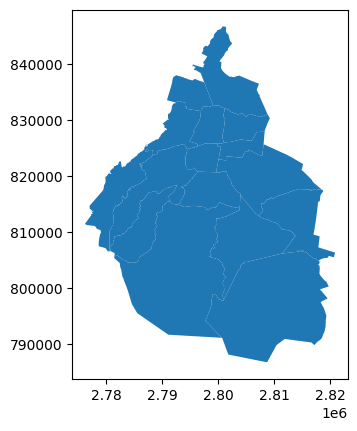

In [5]:
display(mg_mun)
mg_mun.plot()
plt.show()

Es posible obtener los límites de los polígonos con `boundary`

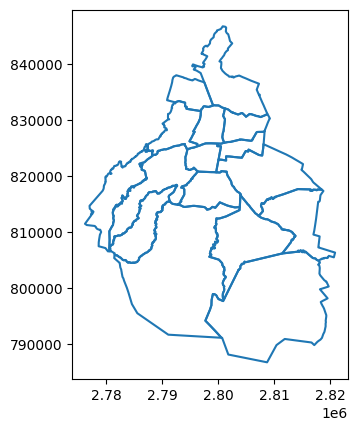

In [6]:
mg_mun.boundary.plot()
plt.show()

También se pueden obtener datos como el area, el centroide, etc. Les recomiendo leer la [documentación de geopandas](https://geopandas.org/en/stable/docs/user_guide/data_structures.html).

In [7]:
mg_mun['geometry'].area

0     3.332309e+07
1     5.362231e+07
2     7.076186e+07
3     8.737831e+07
4     2.296278e+07
5     1.125281e+08
6     6.307477e+07
7     2.967289e+08
8     9.535833e+07
9     8.538328e+07
10    3.128527e+08
11    1.135043e+08
12    2.654892e+07
13    3.233524e+07
14    4.615436e+07
15    3.366605e+07
dtype: float64

### Coordenadas y puntos

En el caso del CLG también hay información espacial de latitud y longitud, las cuales pueden ser vistas como las coordenadas de un punto. Sin embargo, estos datos están en tipo de datos `str` o `float` y no en un formato geospacial `point`. En este caso es necesario realizar una conversión de tipo de datos.

Para lograr esto convertiremos el dataframe `cat_loc` a un geodataframe y usaremos la función `gpd.points_from_xy()` y le especificaremos los datos de longitud y latitud.

Una cosa que es importante notar es si el sistema de coordenadas es equivalente. En general, el INEGI usa WGS84 latitud/longitud "EPSG:4326". Este se establece con el comando `.set_crs()`. 


In [8]:
cat_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627
...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828


In [10]:
cat_loc = gpd.GeoDataFrame(cat_loc, 
                           geometry=gpd.points_from_xy( cat_loc['LON_DECIMAL'], cat_loc['LAT_DECIMAL'])
                          )
cat_loc = cat_loc.set_crs("EPSG:4326")
cat_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS,geometry
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204,POINT (-99.18436 19.4841)
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646,POINT (-99.16215 19.35021)
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530,POINT (-99.29979 19.35735)
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192,POINT (-99.32401 19.31778)
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627,POINT (-99.32568 19.331)
...,...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8,POINT (-99.03953 19.26609)
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175,POINT (-99.15785 19.37199)
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593,POINT (-99.15188 19.44165)
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828,POINT (-99.19075 19.40727)


Ahora, grafiquemos los puntos que corresponden a las cabeceras de cada localidad.

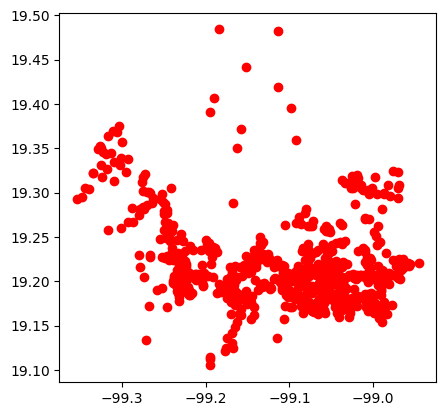

In [11]:
cat_loc.plot(color='red')
plt.show()

## 12.d Mapas

Con Geopandas se pueden crear una variedad de gráficos de mapas para visualizar datos geográficos y su distribución espacial. Algunos de los tipos de gráficos de mapas que se pueden crear con Geopandas son:

* Mapas de coropleta: Son mapas temáticos que representan la distribución espacial de datos cuantitativos agregados por áreas geográficas, como estados, municipios o distritos. La intensidad del color o el tono en cada área del mapa se utiliza para representar el valor de la variable que se está visualizando.
* Mapas de puntos: Muestran la ubicación de puntos en el mapa, que pueden representar puntos de interés, como tiendas, estaciones de transporte, edificios, entre otros. Los puntos se pueden representar con diferentes colores y tamaños para visualizar diferentes variables.
* Mapas de líneas: Representan líneas geográficas, como ríos, carreteras, límites de estados o países, entre otros. Las líneas se pueden etiquetar y colorear según diferentes variables para visualizar patrones o tendencias.
* Mapas de hexágonos: Son mapas de calor que dividen el área geográfica en hexágonos regulares y utilizan la intensidad del color para representar la densidad de los datos.
* Mapas de contorno: Representan las curvas de nivel de las elevaciones del terreno utilizando líneas de contorno. Los mapas de contorno se utilizan comúnmente en la planificación urbana, la ingeniería y la geología.

Agreguemos los datos del censo al dataframe con los polígonos. Es importante evitar tener dos columnas geometry activas al mismo tiempo.

In [12]:
df_loc = mg_loc.merge(cat_loc[['CVEGEO', 'AMBITO', 'POB_TOTAL',  'ALTITUD']], on='CVEGEO', how='inner')
df_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOMGEO,AMBITO_x,geometry,AMBITO_y,POB_TOTAL,ALTITUD
0,090100001,09,010,0001,Álvaro Obregón,Urbana,"POLYGON ((2794395.922 824857.553, 2794434.245 ...",U,759003,2308
1,090120124,09,012,0124,Héroes de 1910,Rural,"POLYGON ((2790456.787 808481.077, 2790465.234 ...",R,571,2947
2,090120290,09,012,0290,La Herradura,Rural,"POLYGON ((2794213.866 807014.135, 2794210.882 ...",R,793,2794
3,090120168,09,012,0168,Chalcuitongo (La Asunción),Rural,"MULTIPOLYGON (((2799620.69 801677, 2799632.478...",R,1048,2748
4,090120161,09,012,0161,El Pedregal,Rural,"POLYGON ((2793380.544 806947.796, 2793372.531 ...",R,822,2869
...,...,...,...,...,...,...,...,...,...,...
86,090090152,09,009,0152,San Lorenzo Tlacoyucan,Urbana,"POLYGON ((2811163.903 801756.629, 2811186.042 ...",U,4288,2616
87,090090300,09,009,0300,San Nicolás Tetelco,Urbana,"POLYGON ((2816936.769 805383.977, 2817231.461 ...",U,4078,2259
88,090150001,09,015,0001,Cuauhtémoc,Urbana,"POLYGON ((2800483.029 832381.312, 2800517.052 ...",U,545884,2230
89,090030001,09,003,0001,Coyoacán,Urbana,"POLYGON ((2799635.191 820691.582, 2799698.587 ...",U,614447,2247


Ahora, grafiquemos el mapa codificando la columna de altitud con una escala de color. Por default `geopandas` usa los mismos parametros que `matplotlib`, por lo que se recomienda cambiar el `cmap`.

<Axes: >

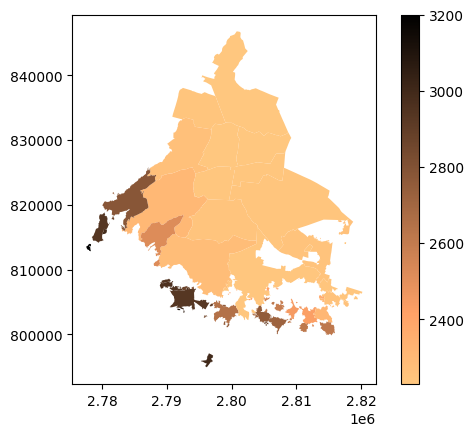

In [13]:
df_loc.plot(column='ALTITUD', cmap='copper_r', legend=True)

Es posible hacer un mapa con multiples capas de datos. En primer lugar es necesario asegurarse que ambos conjuntos de datos tienen el mismo CRS.

In [14]:
cat_loc = cat_loc.to_crs( mg_mun.crs )

Después se genera un plot con la capa base y se pasa ese plot como axes al segundo plot.

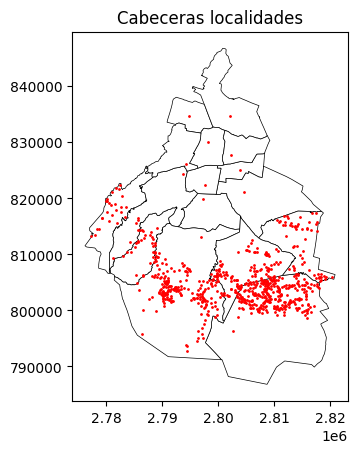

In [15]:
base = mg_mun.plot(color='white', edgecolor='black', linewidth=0.5)
cat_loc.plot(ax=base, color='red', markersize=1)
plt.title('Cabeceras localidades')
plt.show()

Es posible seleccionar partes del mapa a visualizar usando `xlim` y `ylim`. Ten cuidado con usa coordenadas y verificar el orden de magnitud.

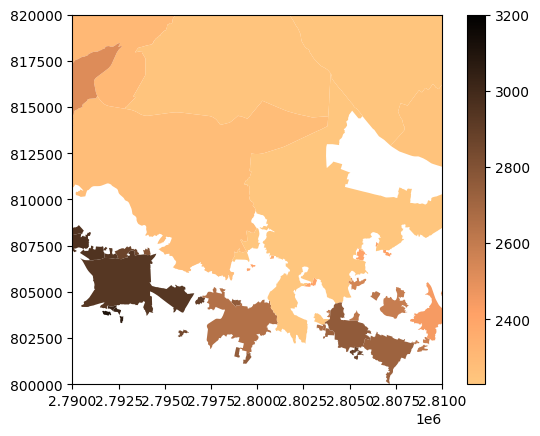

In [16]:
fig, ax = plt.subplots(1, 1)
df_loc.plot(column='ALTITUD', ax=ax, cmap='copper_r', legend=True)
ax.set_xlim(2790000, 2810000)
ax.set_ylim( 800000,  820000)
plt.show()

Existen muchas posibilidades de mapas, incluyendo leyendas, datos faltantes, etc. Les recomiendo leer la [documentación de mapas de geopandas](https://geopandas.org/en/stable/docs/user_guide/mapping.html)

### Etiquetas

Se pueden agregar etiquetas con nombres de lugares para anotar el mapa usando la función `annotate()`, la cual toma un texto y unas coordenadas.

Para usar esta función es necesario volver la geometría `Point` en un par de coordenadas xy. En el caso de poligonos se puede calcular el centroide con `.centroid()` y obtener las coordenadas.

In [17]:
# Convertir Point en coordenadas
cat_loc['coords'] = cat_loc['geometry'].apply(lambda x: x.representative_point().coords[:])
cat_loc['coords'] = [coords[0] for coords in cat_loc['coords']]
cat_loc

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,NOM_LOC,AMBITO,LAT_DECIMAL,LON_DECIMAL,ALTITUD,POB_TOTAL,TOTAL DE VIVIENDAS HABITADAS,geometry,coords
0,090020001,09,002,0001,Azcapotzalco,U,19.48410200,-99.18436000,2244,432205,134204,POINT (2794695 834634.935),"(2794695.0003598714, 834634.9349577167)"
1,090030001,09,003,0001,Coyoacan,U,19.35021400,-99.16214600,2247,614447,191646,POINT (2797312.096 819905.634),"(2797312.096100001, 819905.6339117996)"
2,090040001,09,004,0001,Cuajimalpa de Morelos,U,19.35735000,-99.29979200,2780,186693,52530,POINT (2782878.279 820414.769),"(2782878.278657307, 820414.7694085928)"
3,090040010,09,004,0010,Cruz Blanca,R,19.31778400,-99.32401000,2985,728,192,POINT (2780422.935 816000.447),"(2780422.9350867798, 816000.4469478916)"
4,090040020,09,004,0020,San Lorenzo Acopilco,U,19.33100400,-99.32568100,2937,26042,6627,POINT (2780220.637 817456.251),"(2780220.6369328937, 817456.251081011)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,090130295,09,013,0295,San Sebastian,R,19.26608800,-99.03952800,2231,27,8,POINT (2810348.29 810880.651),"(2810348.2899118382, 810880.6512175137)"
720,090140001,09,014,0001,Benito Juarez,U,19.37199200,-99.15785300,2238,434153,176175,POINT (2797714.166 822317.988),"(2797714.166006976, 822317.9881478926)"
721,090150001,09,015,0001,Cuauhtemoc,U,19.44164600,-99.15188400,2230,545884,196593,POINT (2798186.67 830017.092),"(2798186.669923061, 830017.0923060935)"
722,090160001,09,016,0001,Miguel Hidalgo,U,19.40726900,-99.19075400,2264,414470,146828,POINT (2794191.962 826143.193),"(2794191.9617115394, 826143.1930238209)"


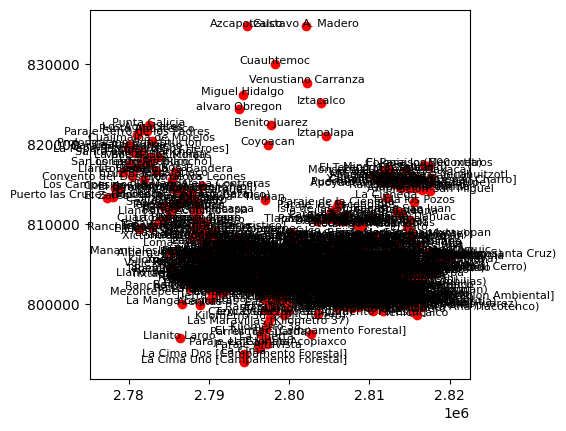

In [20]:
# graficar puntos de ciudades
fig, ax = plt.subplots(1, 1)
cab = cat_loc.plot(ax=ax, color='red')

# agregar una anotación con el nombre de la ciudad por fila
for idx, row in cat_loc.iterrows():  
    cab.annotate(text=row['NOM_LOC'],  xy=row['coords'], 
                    fontsize=8, horizontalalignment='center',  color='black')
plt.show()

### Ejercicio 2

El dataframe `mg_mun` contiene los polígonos de los municipios/alcaldias y `mg_loc` de las localidades.
1. Genera un mapa de lineas con los limites de las alcaldias en negro grueso
2. Asigna el color de la localidad de acuerdo a la población total
3. Agrega el nombre de las alcaldías
4. Grafica las cabeceras de las localidades
5. Selecciona una alcaldía y fija los límites del mapa en ese estado
Nota: ten cuidado con el orden en el que se grafican los mapas.

Dejo un ejemplo con código.

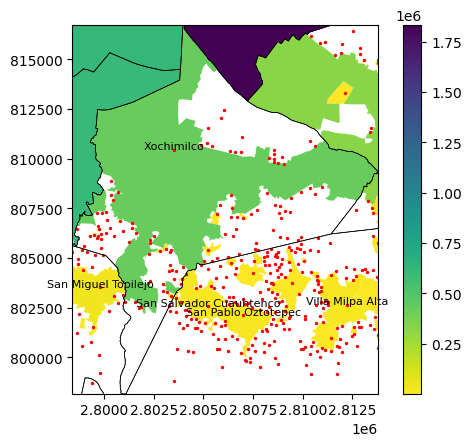

In [21]:
fig, ax = plt.subplots(1, 1)
base_pob = df_loc.plot(ax=ax, column='POB_TOTAL', cmap='viridis_r', legend=True)
base_mun = mg_mun.boundary.plot(ax=base_pob, edgecolor='black', linewidth=0.5)

cab = cat_loc.plot(ax=base_mun, color='red', markersize=2)

# agregar una anotación con el nombre de la localidad por fila
for idx, row in cat_loc.iterrows():
    if row['POB_TOTAL'] >=10000: # etiquetar solo pueblos grandes
        cab.annotate(text=row['NOM_LOC'],  xy=row['coords'], 
                     fontsize=8, horizontalalignment='center',  color='black')

# fijar limites localidad
cve_mun = '013'
bounds = mg_mun.loc[mg_mun['CVE_MUN']==cve_mun].bounds
ax.set_xlim(bounds['minx'].values[0], bounds['maxx'].values[0])
ax.set_ylim(bounds['miny'].values[0], bounds['maxy'].values[0])


plt.show()

## 12.e Mapa con datos propios

A continuación generaremos un mapa con datos propios usando el HBO SEMEFO-DF. En primer lugar carguemos los datos y veamos cuantos ingresos hubo por alcaldía.

In [22]:
from joblib import load

in_file = "data_clean/HBO_clean.pkl"
with open(in_file, 'rb') as f:
     df = load(f)

df_ing_alc = df['Procedencia_alcaldia'].value_counts().reset_index()
df_ing_alc

,Procedencia_alcaldia,count
0,Miguel Hidalgo,11476
1,Cuauhtemoc,11145
2,Gustavo A Madero,9293
3,Venustiano Carranza,9252
4,Benito Juarez,7823
5,Coyoacan,6293
6,Iztapalapa,4698
7,Alvaro Obregon,2649
8,Azcapotzalco,2253
9,Iztacalco,2040


A continuación hay que unir los datos con el marco geoestadístico, en este caso usaremos los nombres de las alcaldías. 

In [23]:
df_ing_alc.merge(mg_mun, left_on='Procedencia_alcaldia', right_on='NOMGEO')

,Procedencia_alcaldia,count,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,Miguel Hidalgo,11476,09016,09,016,Miguel Hidalgo,"POLYGON ((2794088.523 833114.564, 2794079.895 ..."
1,Venustiano Carranza,9252,09017,09,017,Venustiano Carranza,"POLYGON ((2802603.341 831349.5, 2802657.676 83..."
2,Iztapalapa,4698,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ..."
3,Azcapotzalco,2253,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.69 8..."
4,Iztacalco,2040,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ..."
5,Tlalpan,1755,09012,09,012,Tlalpan,"POLYGON ((2793795.253 814557.607, 2793840.057 ..."
6,Xochimilco,1168,09013,09,013,Xochimilco,"POLYGON ((2804014.964 816753.044, 2804027.68 8..."
7,Milpa Alta,254,09009,09,009,Milpa Alta,"POLYGON ((2814877.4 806710.534, 2814871.827 80..."


Si los nombres no coinciden, esto fracasará, para resolver esto es necesario un paso extra de limpieza para estandarizar al catálogo del INEGI. 

En este caso ignoraremos los ingresos que provienen de múltiples alcaldías, lo que significa que hay que solucionar los nombres de:
* Coyoacán, Gustavo A. Madero, La Magdalena Contreras, Álvaro Obregón, Tláhuac, Benito Juárez, Cuauhtémoc

La alcaldía Cuajimalpa no aparece en el HBO.

En este caso es muy importante que el GeoDataFrame este a la izquierda del `merge` para preservar el formato de `geometry`.

In [25]:
dic_replace = {'Coyoacan':'Coyoacán', 'Gustavo A Madero':'Gustavo A. Madero', 'Magdalena Contreras':'La Magdalena Contreras',
        'Alvaro Obregon':'Álvaro Obregón', 'Tlahuac':'Tláhuac', 'Benito Juarez':'Benito Juárez', 'Cuauhtemoc':'Cuauhtémoc'}

df_ing_alc['Procedencia_alcaldia'] = df_ing_alc['Procedencia_alcaldia'].replace(dic_replace)

df_ing_alc = mg_mun.merge(df_ing_alc, right_on='Procedencia_alcaldia', left_on='NOMGEO')
df_ing_alc

/tmp/ipykernel_6092/2461959840.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_ing_alc['Procedencia_alcaldia'] = df_ing_alc['Procedencia_alcaldia'].replace(dic_replace)


,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,Procedencia_alcaldia,count
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.69 8...",Azcapotzalco,2253
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ...",Coyoacán,6293
2,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.66 843326.718, 2801806.564 8...",Gustavo A. Madero,9293
3,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ...",Iztacalco,2040
4,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ...",Iztapalapa,4698
5,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ...",La Magdalena Contreras,369
6,09009,09,009,Milpa Alta,"POLYGON ((2814877.4 806710.534, 2814871.827 80...",Milpa Alta,254
7,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ...",Álvaro Obregón,2649
8,09011,09,011,Tláhuac,"POLYGON ((2816579.32 817395.961, 2816605.02 81...",Tláhuac,390
9,09012,09,012,Tlalpan,"POLYGON ((2793795.253 814557.607, 2793840.057 ...",Tlalpan,1755


Ahora que tenemos la tabla podemos graficar.

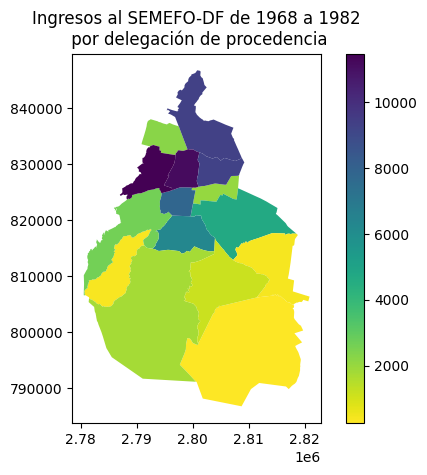

In [26]:
fig, ax = plt.subplots(1, 1)
df_ing_alc.plot(column='count', ax=ax, cmap='viridis_r', legend=True)
plt.title('Ingresos al SEMEFO-DF de 1968 a 1982\n por delegación de procedencia')
plt.show()

## 12.f Temas adicionales

Estos temas están fuera del alcance del tutorial, pero les dejo los links a la documentación.

Las [Coordenadas de Sistema de Referencia (CSR)](https://geopandas.org/en/stable/docs/user_guide/projections.html#coordinate-reference-systems) es un conjunto de reglas y procedimientos que se utilizan para definir y representar la ubicación de objetos y características en la Tierra. Un CSR define un sistema de coordenadas, que es un conjunto de líneas imaginarias que se utilizan para dividir la superficie de la Tierra en regiones más pequeñas y fáciles de ubicar. Los sistemas de referencia pueden ser locales, regionales o globales, y se utilizan en diversas áreas, como la cartografía, la topografía, la geología, la navegación y la ingeniería, entre otras. Los CSR suelen incluir información sobre la forma y el tamaño de la Tierra, así como la ubicación y orientación de las líneas de coordenadas. La elección del CSR adecuado es fundamental para la representación precisa y coherente de la información espacial.

Geopandas incluye soporte de [mapas interactivos](https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html) y para descargar bases de mapas de portales públicos como Google Maps y Open Street Map. 

También permite convertir un nombre de un lugar en una localización geográfica usando [geocoding](https://geopandas.org/en/stable/docs/user_guide/geocoding.html). 

Finalmente, les recomiendo el libro "Cómo mentir con mapas" de Mark Monmonier para aprender más sobre la visualización de mapas.

## 12.g Resumen

En esta lección hemos aprendido varios conceptos:

* Formatos de archivo geoespacial
    * Shapefile, GeoJSON, DBF, entre otros
    * Muchas veces vienen en `.zip`
    * `gpd.read_file()`
* Datos del INEGI
    * Marco Geoestadístico (MGN)
    * Catálogo de Localidad Geoestadística (CLG) 
* Estructuras de datos geoespaciales
    * Polígonos
    * Coordenadas
    * Líneas 
* Graficar mapas
    * Es necesario una columna de `geometry` correctamente formateada
    * Graficar con `gdf.plot()`
    * Agregar varias capas con `gdf.plot(ax=base)`
    * Para graficar mapas propios hay que unir nuestros datos al MGN 

**¡Gracias!**